<a href="https://colab.research.google.com/github/Tharunkoneti18/MLE/blob/main/mle_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install & Import Dependencies
!pip install scikit-learn matplotlib seaborn numpy --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries loaded successfully.")
print(f"NumPy: {np.__version__}")
import sklearn; print(f"Scikit-learn: {sklearn.__version__}")

✅ All libraries loaded successfully.
NumPy: 2.0.2
Scikit-learn: 1.6.1


In [ ]:
# Cell 2: Load & Explore the MNIST Digits Dataset

digits = load_digits()

X = digits.data        # Shape: (1797, 64)
y = digits.target      # Shape: (1797,)
images = digits.images # Shape: (1797, 8, 8)

print("=" * 45)
print("        DATASET OVERVIEW")
print("=" * 45)
print(f"  Total Samples       : {X.shape[0]}")
print(f"  Features per Sample : {X.shape[1]}  (8×8 pixels flattened)")
print(f"  Number of Classes   : {len(np.unique(y))}  (digits 0–9)")
print(f"  Image Shape         : {images[0].shape}")
print(f"  Class Distribution  : {np.bincount(y)}")
print("=" * 45)

        DATASET OVERVIEW
  Total Samples       : 1797
  Features per Sample : 64  (8×8 pixels flattened)
  Number of Classes   : 10  (digits 0–9)
  Image Shape         : (8, 8)
  Class Distribution  : [178 182 177 183 181 182 181 179 174 180]


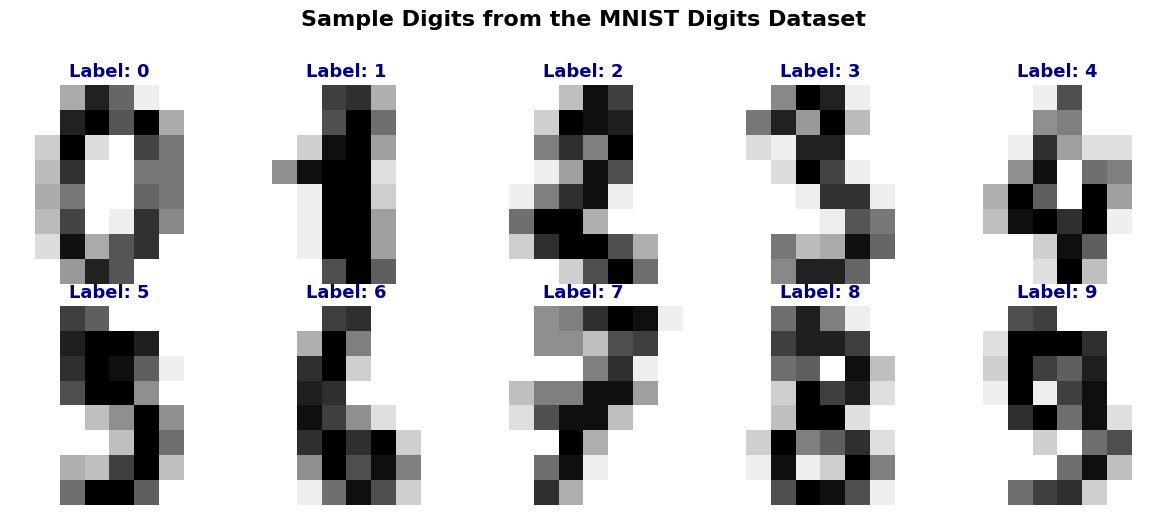

✅ 2×5 digit grid displayed.


In [ ]:
# Cell 3: Visualize a 2×5 Grid of Sample Digits

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Digits from the MNIST Digits Dataset", fontsize=16, fontweight='bold', y=1.02)

for digit in range(10):
    ax = axes[digit // 5][digit % 5]
    # Pick first occurrence of each digit
    idx = np.where(y == digit)[0][0]
    ax.imshow(images[idx], cmap='gray_r', interpolation='nearest')
    ax.set_title(f"Label: {digit}", fontsize=13, fontweight='bold', color='navy')
    ax.axis('off')
    # Draw a border around each subplot
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('steelblue')
        spine.set_linewidth(2)

plt.tight_layout()
plt.savefig("sample_digits_grid.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ 2×5 digit grid displayed.")

In [ ]:
# Cell 4: Preprocessing — Feature Scaling and Train/Test Split

# Features are already flattened 64-dim vectors from load_digits()
# We split BEFORE scaling to prevent data leakage

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y       # Maintain class balance in both splits
)

# StandardScaler: zero mean, unit variance — critical for RBF kernel
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # Transform test with train stats

print("=" * 45)
print("       PREPROCESSING SUMMARY")
print("=" * 45)
print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing  samples : {X_test.shape[0]}")
print(f"  Feature dims     : {X_train.shape[1]}")
print(f"  Train mean (post-scale) ≈ {X_train_scaled.mean():.4f}")
print(f"  Train std  (post-scale) ≈ {X_train_scaled.std():.4f}")
print("=" * 45)

       PREPROCESSING SUMMARY
  Training samples : 1437
  Testing  samples : 360
  Feature dims     : 64
  Train mean (post-scale) ≈ 0.0000
  Train std  (post-scale) ≈ 0.9763


In [ ]:
## 📐 Why Feature Scaling Matters for SVM

"""SVM maximizes the **margin** between classes, which is a **distance-based** computation.
Without scaling:
- Features with larger ranges dominate the distance calculation.
- The RBF kernel is especially sensitive because it computes $\|x - x'\|^2$ — unscaled features cause the kernel to behave erratically.

**`StandardScaler`** transforms each feature $x_j$ as:

$$x_j' = \frac{x_j - \mu_j}{\sigma_j}$$

This ensures all 64 pixel features contribute equally to the kernel computation
"""

"SVM maximizes the **margin** between classes, which is a **distance-based** computation.\nWithout scaling:\n- Features with larger ranges dominate the distance calculation.\n- The RBF kernel is especially sensitive because it computes $\\|x - x'\\|^2$ — unscaled features cause the kernel to behave erratically.\n\n**`StandardScaler`** transforms each feature $x_j$ as:\n\n$$x_j' = \x0crac{x_j - \\mu_j}{\\sigma_j}$$\n\nThis ensures all 64 pixel features contribute equally to the kernel computation\n"

In [ ]:
# Cell 6: Baseline — Linear SVM (no kernel trick)

print("Training Baseline Linear SVM...")

linear_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE))
])

linear_svm.fit(X_train, y_train)
y_pred_linear = linear_svm.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_linear)

print("\n" + "=" * 45)
print("     BASELINE LINEAR SVM RESULTS")
print("=" * 45)
print(f"  Accuracy  : {baseline_accuracy * 100:.2f}%")
print("=" * 45)
print("\nClassification Report (Linear SVM):")
print(classification_report(y_test, y_pred_linear, target_names=[str(i) for i in range(10)]))

Training Baseline Linear SVM...

     BASELINE LINEAR SVM RESULTS
  Accuracy  : 97.50%

Classification Report (Linear SVM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      0.94      0.93        36
           2       1.00      1.00      1.00        35
           3       0.97      0.97      0.97        37
           4       1.00      1.00      1.00        36
           5       1.00      0.97      0.99        37
           6       1.00      1.00      1.00        36
           7       0.95      1.00      0.97        36
           8       0.97      0.89      0.93        35
           9       0.95      0.97      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360



In [ ]:
# Cell 8: RBF Kernel SVM with Default Parameters

print("Training RBF SVM (default C=1.0, gamma='scale')...")

rbf_svm_default = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE))
])

rbf_svm_default.fit(X_train, y_train)
y_pred_rbf_default = rbf_svm_default.predict(X_test)

rbf_default_accuracy = accuracy_score(y_test, y_pred_rbf_default)

print("\n" + "=" * 45)
print("   RBF SVM (DEFAULT PARAMS) RESULTS")
print("=" * 45)
print(f"  Accuracy  : {rbf_default_accuracy * 100:.2f}%")
print(f"  Δ vs Linear Baseline: +{(rbf_default_accuracy - baseline_accuracy)*100:.2f}%")
print("=" * 45)

Training RBF SVM (default C=1.0, gamma='scale')...

   RBF SVM (DEFAULT PARAMS) RESULTS
  Accuracy  : 97.50%
  Δ vs Linear Baseline: +0.00%


In [ ]:
# Cell 9: Hyperparameter Tuning — GridSearchCV with Pipeline

print("🔍 Running GridSearchCV (this may take ~1–2 minutes)...\n")

# Define Pipeline (scaler inside prevents data leakage across CV folds)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', random_state=RANDOM_STATE))
])

# Search space as defined in requirements
param_grid = {
    'svm__C'     : [0.1, 1, 10, 100],
    'svm__gamma' : [0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,             # Use all CPU cores
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)

print("\n" + "=" * 50)
print("       GRIDSEARCHCV RESULTS")
print("=" * 50)
print(f"  Best Params       : {grid_search.best_params_}")
print(f"  Best CV Accuracy  : {grid_search.best_score_ * 100:.2f}%")
print(f"  Test Accuracy     : {best_accuracy * 100:.2f}%")
print(f"  Δ vs Baseline     : +{(best_accuracy - baseline_accuracy)*100:.2f}%")
print("=" * 50)

🔍 Running GridSearchCV (this may take ~1–2 minutes)...

Fitting 5 folds for each of 16 candidates, totalling 80 fits

       GRIDSEARCHCV RESULTS
  Best Params       : {'svm__C': 100, 'svm__gamma': 0.01}
  Best CV Accuracy  : 98.33%
  Test Accuracy     : 98.33%
  Δ vs Baseline     : +0.83%


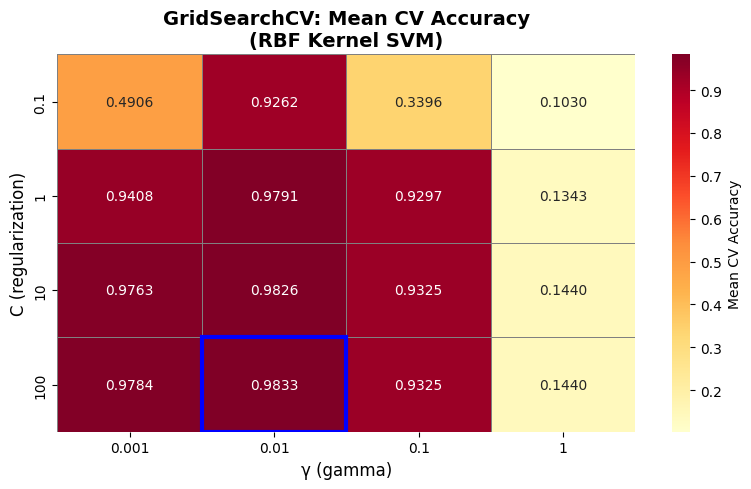

✅ Best: C=100, γ=0.01


In [ ]:
# Cell 10: Visualize GridSearchCV Results as Heatmap

import pandas as pd

results = grid_search.cv_results_
scores = results['mean_test_score'].reshape(len(param_grid['svm__C']),
                                             len(param_grid['svm__gamma']))

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    scores,
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    xticklabels=param_grid['svm__gamma'],
    yticklabels=param_grid['svm__C'],
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Mean CV Accuracy'},
    ax=ax
)

ax.set_title('GridSearchCV: Mean CV Accuracy\n(RBF Kernel SVM)', fontsize=14, fontweight='bold')
ax.set_xlabel('γ (gamma)', fontsize=12)
ax.set_ylabel('C (regularization)', fontsize=12)

# Highlight best cell
best_C_idx     = param_grid['svm__C'].index(grid_search.best_params_['svm__C'])
best_gamma_idx = param_grid['svm__gamma'].index(grid_search.best_params_['svm__gamma'])
ax.add_patch(plt.Rectangle((best_gamma_idx, best_C_idx), 1, 1,
                             fill=False, edgecolor='blue', lw=3, label='Best Params'))

plt.tight_layout()
plt.savefig("gridsearch_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Best: C={grid_search.best_params_['svm__C']}, γ={grid_search.best_params_['svm__gamma']}")

In [ ]:
# Cell 11: Detailed Classification Report (Best Model)

print("=" * 55)
print("   CLASSIFICATION REPORT — Best RBF SVM")
print("=" * 55)
print(classification_report(
    y_test, y_pred_best,
    target_names=[f"Digit {i}" for i in range(10)]
))

   CLASSIFICATION REPORT — Best RBF SVM
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00        36
     Digit 1       0.97      0.97      0.97        36
     Digit 2       1.00      1.00      1.00        35
     Digit 3       1.00      1.00      1.00        37
     Digit 4       0.95      0.97      0.96        36
     Digit 5       1.00      1.00      1.00        37
     Digit 6       0.97      1.00      0.99        36
     Digit 7       0.95      1.00      0.97        36
     Digit 8       1.00      0.94      0.97        35
     Digit 9       1.00      0.94      0.97        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



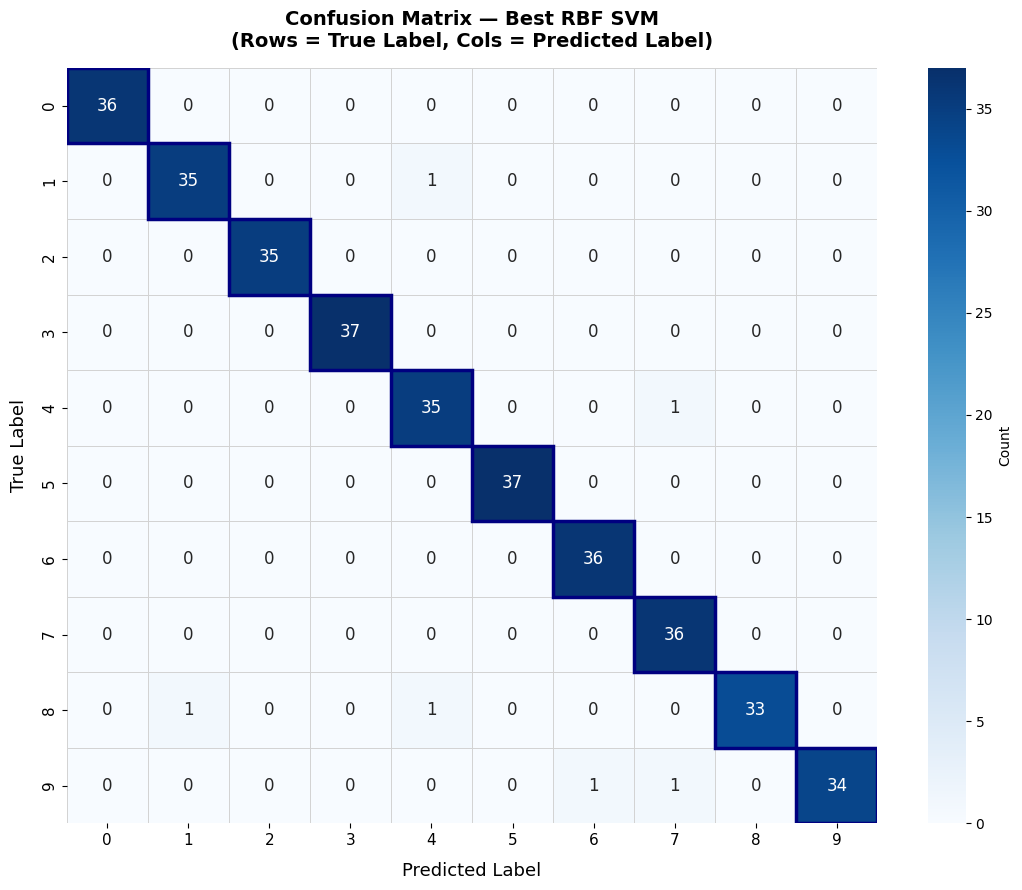


Per-Class Accuracy:
  Digit 0: 100.0%
  Digit 1: 97.2%
  Digit 2: 100.0%
  Digit 3: 100.0%
  Digit 4: 97.2%
  Digit 5: 100.0%
  Digit 6: 100.0%
  Digit 7: 100.0%
  Digit 8: 94.3%
  Digit 9: 94.4%


In [ ]:
# Cell 12: 10×10 Confusion Matrix as Seaborn Heatmap

cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10),
    linewidths=0.5,
    linecolor='lightgray',
    cbar_kws={'label': 'Count'},
    annot_kws={"size": 12},
    ax=ax
)

ax.set_title('Confusion Matrix — Best RBF SVM\n(Rows = True Label, Cols = Predicted Label)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=13, labelpad=10)
ax.set_ylabel('True Label', fontsize=13, labelpad=10)
ax.tick_params(axis='both', labelsize=11)

# Highlight diagonal (correct predictions)
for i in range(10):
    ax.add_patch(plt.Rectangle((i, i), 1, 1,
                                fill=False, edgecolor='navy', lw=2.5))

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# Print per-class accuracy from confusion matrix
print("\nPer-Class Accuracy:")
for i in range(10):
    class_acc = cm[i, i] / cm[i].sum() * 100
    print(f"  Digit {i}: {class_acc:.1f}%")

Total misclassified: 6 / 360
Error rate: 1.67%



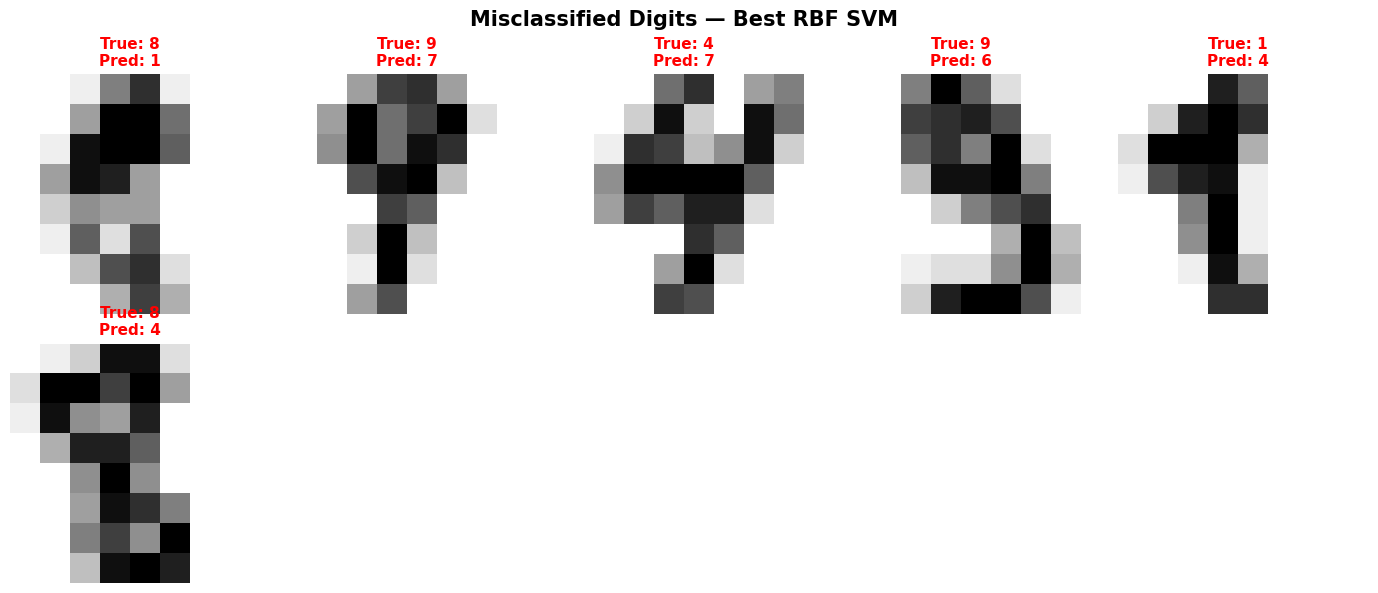

In [ ]:
# Cell 13: Visualize Misclassified Digits

# Find all misclassified indices
misclassified_idx = np.where(y_pred_best != y_test)[0]

print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")
print(f"Error rate: {len(misclassified_idx)/len(y_test)*100:.2f}%\n")

# Display first 10 misclassified (2 rows × 5 cols)
n_show = min(10, len(misclassified_idx))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Misclassified Digits — Best RBF SVM", fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = misclassified_idx[i]
        # Reconstruct 8×8 image from scaled test features (inverse transform)
        img = scaler.inverse_transform(X_test_scaled[idx].reshape(1, -1)).reshape(8, 8)
        ax.imshow(img, cmap='gray_r', interpolation='nearest')
        ax.set_title(f"True: {y_test[idx]}\nPred: {y_pred_best[idx]}",
                     fontsize=11,
                     color='red' if y_test[idx] != y_pred_best[idx] else 'green',
                     fontweight='bold')
        ax.axis('off')
        # Red border for misclassified
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor('crimson')
            spine.set_linewidth(2.5)
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig("misclassified_digits.png", dpi=150, bbox_inches='tight')
plt.show()

KNN (k=5) Distance Metric Comparison on Scaled Features
  Euclidean (p=2)          : Accuracy = 96.39%
  Manhattan (p=1)          : Accuracy = 98.89%
  Minkowski (p=3)          : Accuracy = 96.94%
  RBF-SVM (Best)           : Accuracy = 98.33%


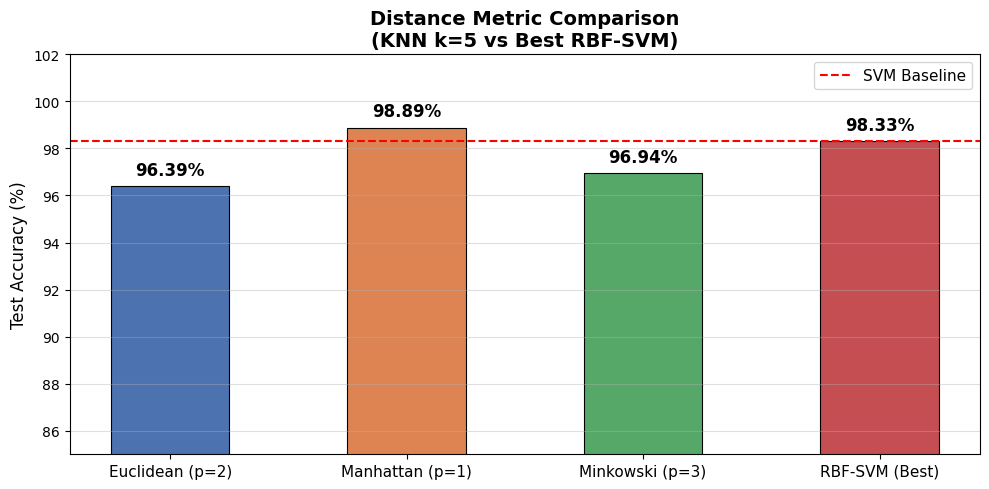

In [ ]:
# Cell 15: Distance Metric Comparison using KNN as a controlled proxy

from sklearn.neighbors import KNeighborsClassifier

metrics = {
    'Euclidean (p=2)' : {'metric': 'minkowski', 'p': 2},
    'Manhattan (p=1)' : {'metric': 'minkowski', 'p': 1},
    'Minkowski (p=3)' : {'metric': 'minkowski', 'p': 3},
}

k = 5  # Fixed k for fair comparison
metric_results = {}

print(f"KNN (k={k}) Distance Metric Comparison on Scaled Features")
print("=" * 55)

for name, kwargs in metrics.items():
    knn = KNeighborsClassifier(n_neighbors=k, **kwargs)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_knn)
    metric_results[name] = acc
    print(f"  {name:<25}: Accuracy = {acc*100:.2f}%")

# Add Best SVM for reference
metric_results['RBF-SVM (Best)'] = best_accuracy
print(f"  {'RBF-SVM (Best)':<25}: Accuracy = {best_accuracy*100:.2f}%")
print("=" * 55)

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
bars = ax.bar(metric_results.keys(),
              [v*100 for v in metric_results.values()],
              color=colors, edgecolor='black', linewidth=0.8, width=0.5)

# Annotate bars
for bar, val in zip(bars, metric_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val*100:.2f}%",
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Distance Metric Comparison\n(KNN k=5 vs Best RBF-SVM)', fontsize=14, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_ylim(85, 102)
ax.axhline(y=best_accuracy*100, color='red', linestyle='--', linewidth=1.5, label='SVM Baseline')
ax.legend(fontsize=11)
ax.tick_params(axis='x', labelsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig("distance_metric_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 17: Final Summary Table

print("\n" + "=" * 55)
print("         FINAL MODEL COMPARISON SUMMARY")
print("=" * 55)

summary = {
    "Linear SVM (baseline)"       : baseline_accuracy,
    "RBF SVM (default C=1, γ=scale)": rbf_default_accuracy,
    "RBF SVM (GridSearchCV tuned)" : best_accuracy,
    "KNN Euclidean (k=5)"         : metric_results['Euclidean (p=2)'],
    "KNN Manhattan (k=5)"         : metric_results['Manhattan (p=1)'],
    "KNN Minkowski p=3 (k=5)"     : metric_results['Minkowski (p=3)'],
}

for model, acc in summary.items():
    bar = "█" * int(acc * 50)
    print(f"  {model:<38}: {acc*100:5.2f}%  {bar}")

print("=" * 55)
print(f"\n🏆 Best Model: RBF SVM with GridSearchCV")
print(f"   Params : C={grid_search.best_params_['svm__C']}, γ={grid_search.best_params_['svm__gamma']}")
print(f"   Accuracy: {best_accuracy*100:.2f}%")
print("\n✅ Notebook complete.")


         FINAL MODEL COMPARISON SUMMARY
  Linear SVM (baseline)                 : 97.50%  ████████████████████████████████████████████████
  RBF SVM (default C=1, γ=scale)        : 97.50%  ████████████████████████████████████████████████
  RBF SVM (GridSearchCV tuned)          : 98.33%  █████████████████████████████████████████████████
  KNN Euclidean (k=5)                   : 96.39%  ████████████████████████████████████████████████
  KNN Manhattan (k=5)                   : 98.89%  █████████████████████████████████████████████████
  KNN Minkowski p=3 (k=5)               : 96.94%  ████████████████████████████████████████████████

🏆 Best Model: RBF SVM with GridSearchCV
   Params : C=100, γ=0.01
   Accuracy: 98.33%

✅ Notebook complete.
